# Computational-time comparison

Grouped bar chart of solve times from the supplied table. Times are in milliseconds. The PTL-PINN no-invert results are omitted.

In [21]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "cm",
    "text.usetex": False,
})

## Data

In [22]:
equations = [
    "Undamped",
    "Underdamped",
    "Overdamped",
    "Fisher–KPP",
    "Wave equation",
]

# Computational times in milliseconds. The ζ=0.4 underdamped case and the
# ζ=30 overdamped case are retained; ζ=30 most favors PTL-PINN no-invert.
times = {
    "RK45": np.array([28.9, 4.7, 2.0, 47.7, 64.4]),
    "Radau": np.array([11.1, 1.2, 22.8, 6.2, 263.8]),
    "Transfer learning": np.array([2.4e4, 1.4e5, 7.75e5, 6.5e3, 8.3e3]),
    "PTL-PINN": np.array([4.8, 1.1, 1.1, 15.0, 18.3]),
}

## Grouped computational-time histogram

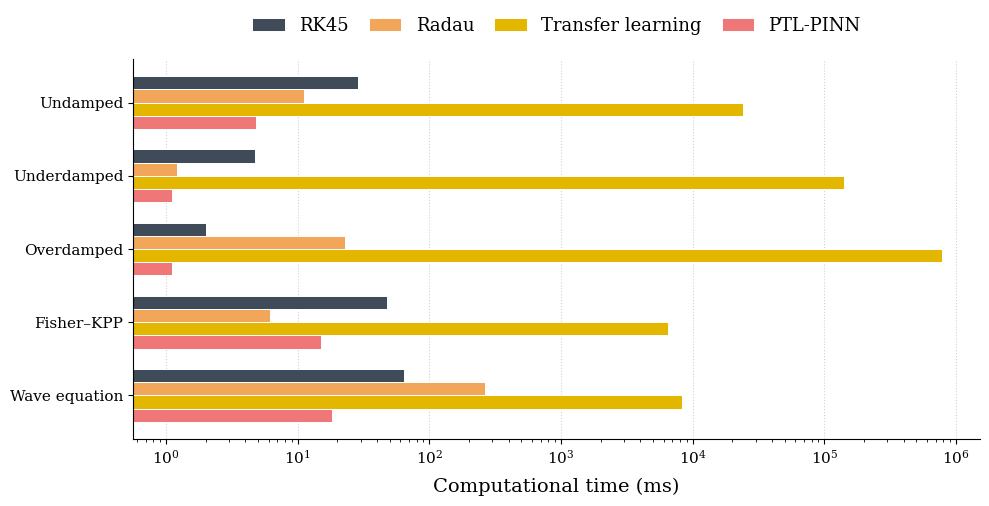

In [23]:
LABEL_SIZE = 14
TICK_SIZE = 11
LEGEND_SIZE = 13

# Tones used in the graphical abstract: slate, orange, yellow, and coral.
colors = ["#3F4B59", "#F2A65A", "#E3B600", "#EF7777"]
y = np.arange(len(equations))
bar_height = 0.18
offsets = (np.arange(len(times)) - (len(times) - 1) / 2) * bar_height

# Landscape version with horizontal bars.
fig, ax = plt.subplots(figsize=(10, 5.5))

for offset, (solver, values), color in zip(offsets, times.items(), colors):
    ax.barh(
        y + offset,
        values,
        height=bar_height,
        label=solver,
        color=color,
        edgecolor="white",
        linewidth=0.7,
    )

# The measurements span almost six orders of magnitude.
ax.set_xscale("log")
ax.set_xlabel("Computational time (ms)", fontsize=LABEL_SIZE, labelpad=8)
ax.set_yticks(y)
ax.set_yticklabels(equations)
ax.invert_yaxis()
ax.tick_params(axis="both", labelsize=TICK_SIZE)
ax.grid(axis="x", which="major", linestyle=":", color="#3F4B59", alpha=0.25)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=4,
    fontsize=LEGEND_SIZE,
    frameon=False,
    columnspacing=1.1,
    handlelength=1.8,
)

fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("computational_times_histogram.pdf", bbox_inches="tight", dpi=300)
plt.savefig("computational_times_histogram.png", bbox_inches="tight", dpi=300)
plt.show()